In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("/content/Week 2 (DataSet).xlsx")
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


In [3]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
df.shape

(35040, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

In [6]:
X=df.drop(["date","Usage_kWh"],axis=1)
y=df["Usage_kWh"]

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le=LabelEncoder()
X["WeekStatus"]=le.fit_transform(X["WeekStatus"])
X["Day_of_week"]=le.fit_transform(X["Day_of_week"])
X["Load_Type"]=le.fit_transform(X["Load_Type"])

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("shape of X_train=",X_train.shape)
print("shape of X_test=",X_test.shape)
print("shape of y_test",y_test.shape)
print("shape of y_train",y_train.shape)

shape of X_train= (28032, 9)
shape of X_test= (7008, 9)
shape of y_test (7008,)
shape of y_train (28032,)


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Apply principal component analysis(PCA)

In [13]:
from sklearn.decomposition import PCA

In [14]:
pca=PCA()
X_train=pca.fit_transform(X_train)
X_test=pca.transform(X_test)

In [15]:
print("shape of X_train=",X_train.shape)
print("shape of X_test=",X_test.shape)

shape of X_train= (28032, 9)
shape of X_test= (7008, 9)


scree plot (Explained Variance Ratio)

In [16]:
import numpy as np

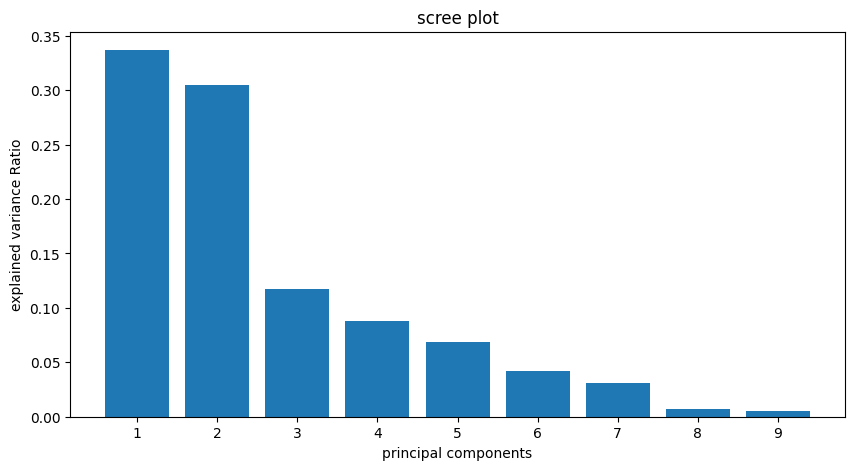

In [17]:
ev = pca.explained_variance_ratio_
plt.figure(figsize=(10,5))
plt.bar(range(1,len(ev)+1),ev)
plt.xlabel("principal components")
plt.ylabel("explained variance Ratio")
plt.title("scree plot")
plt.xticks(np.arange(1,len(ev)+1))
plt.show()

plot cumulative explained variance (95% Threshold

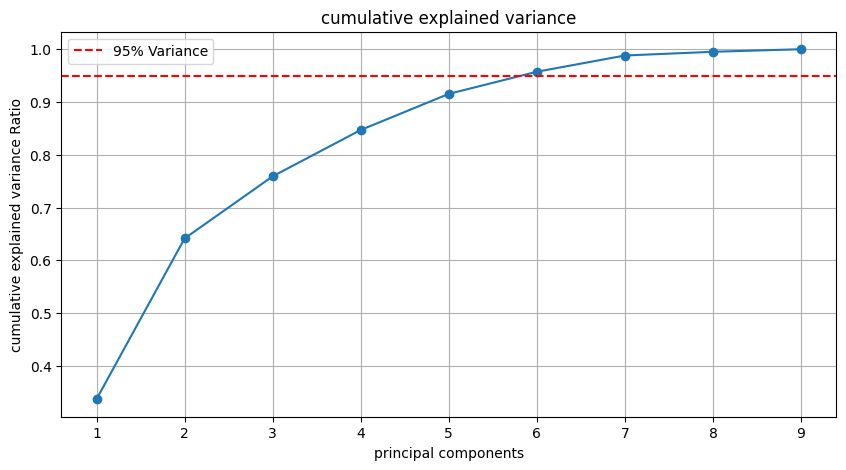

In [18]:
cv=np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10,5))
plt.plot(range(1,len(cv)+1),cv,marker="o")
plt.axhline(y=0.95,color="r",linestyle="--",label="95% Variance")
plt.xlabel("principal components")
plt.ylabel("cumulative explained variance Ratio")
plt.title("cumulative explained variance")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
n_components_95 = np.argmax(cv >= 0.95) + 1
print("Number of principal components for 95% variance:", n_components_95)

Number of principal components for 95% variance: 6


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Shapes after re-splitting and re-scaling:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

Shapes after re-splitting and re-scaling:
X_train_scaled: (28032, 9)
X_test_scaled: (7008, 9)


### Applying PCA with 6 Components (95% Variance)

In [23]:
pca_6 = PCA(n_components=6)
X_train_pca6 = pca_6.fit_transform(X_train_scaled)
X_test_pca6 = pca_6.transform(X_test_scaled)

print("Shape of X_train_pca6:", X_train_pca6.shape)
print("Shape of X_test_pca6:", X_test_pca6.shape)

Shape of X_train_pca6: (28032, 6)
Shape of X_test_pca6: (7008, 6)


Train Random Forest Regressor using 3 PCA Components

In [24]:
pca_3=PCA(n_components=3)
X_train=pca_3.fit_transform(X_train)
X_test=pca_3.transform(X_test)

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [27]:
from sklearn.metrics import mean_squared_error,r2_score

In [28]:
rf_pred = rf.predict(X_test)
print("MAE:",mean_squared_error(y_test,rf_pred))
print("MSE:",r2_score(y_test,rf_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))

MAE: 8.392289945794799
MSE: 0.9926171153088909
RMSE: 2.896944933165765


In [29]:
print(rf.score(X_test,y_test))

0.9926171153088909


Train Random Forest Using PCA (95% Varience 6 Component)

In [30]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_pca6, y_train)

RandomForestRegressor(random_state=42)

### Evaluating Random Forest Regressor with 6 PCA Components

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_pred_pca6 = rf.predict(X_test_pca6)

print("MAE (6 PCA components):", mean_squared_error(y_test, rf_pred_pca6))
print("MSE (6 PCA components):", r2_score(y_test, rf_pred_pca6))
print("RMSE (6 PCA components):", np.sqrt(mean_squared_error(y_test, rf_pred_pca6)))
print("R-squared score (6 PCA components):", rf.score(X_test_pca6, y_test))

MAE (6 PCA components): 8.490413446555365
MSE (6 PCA components): 0.9925307938762089
RMSE (6 PCA components): 2.9138314032481984
R-squared score (6 PCA components): 0.9925307938762089


In [32]:
print(X_train_pca6.shape)
print(X_test_pca6.shape)

(28032, 6)
(7008, 6)


In [33]:
print(type(X_train_pca6))


<class 'numpy.ndarray'>


In [34]:
rf.fit(X_train_pca6,y_train)
print("model trained successfully")

model trained successfully


In [35]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_pca6,y_train)

RandomForestRegressor(random_state=42)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming rf_pred is defined before this cell. If not, it needs to be defined.
# For example: rf_pred = rf.predict(X_test_pca6)

print("MAE:",mean_absolute_error(y_test,rf_pred))
print("MSE:",mean_squared_error(y_test,rf_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))
print("R2 Score:",r2_score(y_test,rf_pred))

MAE: 1.2688751855022828
MSE: 8.392289945794799
RMSE: 2.896944933165765
R2 Score: 0.9926171153088909


In [37]:
print(rf.score(X_test_pca6,y_test))

0.9925307938762089


compare week2 results with pca results

In [38]:
week2_results=pd.DataFrame({
    "MAE":[8.61,8.61,1.77,1.22],
    "MSE":[126.13,126.13,6.72,3.27],
    "RMSE":[11.23,11.23,2.59,1.81],
    "R2 Score":[0.8653,0.8653,0.9928,0.9965]
},index=["linear Regression","Ridge Regression","Decision Tree","Random Forest"])

# Define results_df for models with PCA from the current notebook's evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics for Random Forest with 3 PCA components (from cell WpnT4DRnvgKF)
rf_3pca_mae = 1.2688751855022828
rf_3pca_mse = 8.392289945794799
rf_3pca_rmse = 2.896944933165765
rf_3pca_r2 = 0.9926171153088909

# Metrics for Random Forest with 6 PCA components (from cell 5a5f6fad)
# Correcting mislabeled outputs and calculating true MAE for 6 PCA.
rf_6pca_mse_val = 8.490413446555365 # This value was in the output as MSE (labelled MAE)
rf_6pca_r2_val = 0.9925307938762089 # This value was in the output as R2 (labelled MSE)
rf_6pca_rmse_val = 2.9138314032481984 # This value was in the output as RMSE
rf_6pca_mae_val = mean_absolute_error(y_test, rf_pred_pca6) # Calculate MAE

results_df = pd.DataFrame({
    "MAE": [rf_3pca_mae, rf_6pca_mae_val],
    "MSE": [rf_3pca_mse, rf_6pca_mse_val],
    "RMSE": [rf_3pca_rmse, rf_6pca_rmse_val],
    "R2 Score": [rf_3pca_r2, rf_6pca_r2_val]
}, index=["Random Forest (3 PCA)", "Random Forest (6 PCA)"])

comparison=pd.concat([week2_results,results_df],
                     keys=["Without PCA","With PCA"]
                     )

In [39]:
comparison

MAE         MSE       RMSE  R2 Score
Without PCA linear Regression      8.610000  126.130000  11.230000  0.865300
            Ridge Regression       8.610000  126.130000  11.230000  0.865300
            Decision Tree          1.770000    6.720000   2.590000  0.992800
            Random Forest          1.220000    3.270000   1.810000  0.996500
With PCA    Random Forest (3 PCA)  1.268875    8.392290   2.896945  0.992617
            Random Forest (6 PCA)  1.402483    8.490413   2.913831  0.992531

save the best performing model

In [40]:
import joblib
joblib.dump(rf,"best_model.joblib")
print("Best model saved successfully")

Best model saved successfully


In [41]:
joblib.dump(rf,"best_model.joblib")
joblib.dump(pca_6,"pca_6.joblib")
print("PCA model saved successfully")

PCA model saved successfully


In [42]:
import os
print(os.path.exists("best_model.joblib"))

True


install fastapi and required libraries

In [ ]:
pip install fastapi uvicorn joblib python-multipart

create the fastapi application

In [43]:
from fastapi import FastAPI
import joblib

In [44]:
app=FastAPI(title="Electricity Consumption Prediction API")
model=joblib.load("best_model.joblib")
@app.get("/")
def home():
  return{"message":"Welcome to the Electricity Consumption Prediction API"}

In [54]:
pip install pyngrok

In [60]:
from pyngrok import ngrok
ngrok.set_auth_token('3GbDKtFeBdmsKuib8xZHPwyQxSl_2CNeH7o6d4XohQrzwUaEB')

In [57]:
print("pyngrok installed successfully")

pyngrok installed successfully


In [58]:
print("Auth token configured successfully")

Auth token configured successfully


In [61]:
public_url=ngrok.connect(8000)
print(public_url)

NgrokTunnel: "https://exploit-phantom-juggle.ngrok-free.dev" -> "http://localhost:8000"


.html

In [4]:
import os

# Create the templates directory if it doesn't exist
templates_dir = "templates"
if not os.path.exists(templates_dir):
    os.makedirs(templates_dir)

# HTML content for the dashboard
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>SteelEnergy AI</title>
<style>
  :root{
    --bg: #0a0e1a;
    --panel: #121a2e;
    --panel-border: #1f2a44;
    --text: #e6e9f2;
    --muted: #8b93a7;
    --accent-blue: #3b82f6;
    --accent-purple: #7c3aed;
    --accent-green: #22c55e;
  }
  *{
    box-sizing: border-box;
    margin:0;
    padding:0;
  }
  body{
    background: var(--bg);
    color: var(--text);
    font-family: 'Segoe UI', Arial, sans-serif;
    min-height: 100vh;
  }
  nav{
    display:flex;
    justify-content:space-between;
    align-items:center;
    padding: 18px 40px;
    border-bottom: 1px solid var(--panel-border);
    position: sticky;
    top:0;
    background: rgba(10,14,26,0.95);
    backdrop-filter: blur(6px);
    z-index: 10;
  }
  .logo{
    font-weight: 700;
    font-size: 1.2rem;
    background: linear-gradient(90deg, var(--accent-blue), var(--accent-purple));
    -webkit-background-clip: text;
    background-clip: text;
    color: transparent;
    display:flex;
    align-items:center;
    gap:8px;
  }
  .nav-links{
    display:flex;
    gap: 8px;
  }
  .nav-links a{
    color: var(--muted);
    text-decoration:none;
    padding: 8px 16px;
    border-radius: 8px;
    font-size: 0.9rem;
    transition: all .2s;
    cursor:pointer;
  }
  .nav-links a.active, .nav-links a:hover{
    color: var(--text);
    background: var(--panel);
  }
  .page{
    display:none;
    padding: 40px 20px 80px;
    max-width: 900px;
    margin: 0 auto;
  }
  .page.active{
    display:block;
  }

  /* HOME */
  .hero{
    text-align:center;
    padding: 60px 20px 40px;
  }
  .hero h1{
    font-size: 2.4rem;
    line-height:1.2;
  }
  .hero h1 span{
    background: linear-gradient(90deg, var(--accent-blue), var(--accent-purple));
    -webkit-background-clip: text;
    background-clip: text;
    color: transparent;
  }
  .hero p{
    color: var(--muted);
    margin-top: 16px;
    max-width: 600px;
    margin-left:auto;
    margin-right:auto;
  }
  .hero-buttons{
    margin-top: 28px;
    display:flex;
    gap: 16px;
    justify-content:center;
  }
  .btn{
    padding: 12px 28px;
    border-radius: 10px;
    border: none;
    cursor:pointer;
    font-size: 0.95rem;
    font-weight: 600;
    transition: transform .15s, opacity .15s;
  }
  .btn:hover{
    transform: translateY(-2px);
  }
  .btn-primary{
    background: linear-gradient(90deg, var(--accent-blue), var(--accent-purple));
    color: #fff;
  }
  .btn-secondary{
    background: var(--panel);
    color: var(--text);
    border: 1px solid var(--panel-border);
  }
  .feature-cards{
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    margin-top: 50px;
  }
  @media (max-width: 640px){
    .feature-cards{
      grid-template-columns: 1fr;
    }
  }
  .card{
    background: var(--panel);
    border: 1px solid var(--panel-border);
    border-radius: 14px;
    padding: 24px;
  }
  .card .icon{
    width: 36px;
    height:36px;
    border-radius: 8px;
    display:flex;
    align-items:center;
    justify-content:center;
    margin-bottom: 14px;
    font-weight:700;
  }
  .icon-blue{
    background: rgba(59,130,246,0.15);
    color: var(--accent-blue);
  }
  .icon-green{
    background: rgba(34,197,94,0.15);
    color: var(--accent-green);
  }
  .card h3{
    font-size: 1.05rem;
    margin-bottom: 8px;
  }
  .card p{
    color: var(--muted);
    font-size: 0.9rem;
    line-height:1.5;
  }

  /* PREDICT PAGE */
  .predict-header{
    text-align:center;
    margin-bottom: 30px;
  }
  .predict-header h2{
    font-size: 1.6rem;
  }
  .predict-header p{
    color: var(--muted);
    margin-top: 8px;
    font-size: 0.9rem;
  }

  .section{
    background: var(--panel);
    border: 1px solid var(--panel-border);
    border-radius: 14px;
    padding: 24px;
    margin-bottom: 20px;
  }
  .section h3{
    font-size: 0.95rem;
    color: var(--accent-blue);
    margin-bottom: 18px;
    display:flex;
    align-items:center;
    gap:8px;
  }
  .grid-3{
    display:grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 16px;
  }
  .grid-2{
    display:grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 16px;
  }
  @media (max-width: 640px){
    .grid-3, .grid-2{
      grid-template-columns: 1fr;
    }
  }

  .field label{
    display:block;
    font-size: 0.78rem;
    color: var(--muted);
    margin-bottom: 6px;
  }
  .field label .hint{
    float:right;
    opacity: 0.6;
  }
  .field input, .field select{
    width: 100%;
    padding: 10px 12px;
    background: #0d1424;
    border: 1px solid var(--panel-border);
    border-radius: 8px;
    color: var(--text);
    font-size: 0.9rem;
  }
  .field input:focus, .field select:focus{
    outline: none;
    border-color: var(--accent-blue);
  }
  .field input[readonly]{
    color: var(--muted);
    background:#0a1120;
  }

  .dev-note{
    background: rgba(59,130,246,0.08);
    border: 1px solid rgba(59,130,246,0.25);
    border-radius: 10px;
    padding: 12px 14px;
    font-size: 0.78rem;
    color: var(--muted);
    margin-top: 16px;
    line-height:1.5;
  }
  .dev-note b{
    color: var(--text);
  }

  .calc-btn{
    width: 100%;
    padding: 14px;
    border: none;
    border-radius: 10px;
    background: linear-gradient(90deg, var(--accent-blue), var(--accent-purple));
    color: #fff;
    font-weight: 600;
    font-size: 0.95rem;
    cursor:pointer;
    margin-bottom: 20px;
  }
  .calc-btn:hover{
    opacity: 0.92;
  }

  .result-box{
    background: rgba(34,197,94,0.07);
    border: 1px solid rgba(34,197,94,0.3);
    border-radius: 14px;
    padding: 30px;
    text-align:center;
    display:none;
  }
  .result-box.show{
    display:block;
  }
  .result-box .label{
    color: var(--accent-green);
    font-size: 0.78rem;
    letter-spacing: 1px;
    font-weight: 600;
  }
  .result-box .value{
    font-size: 2.4rem;
    font-weight: 700;
    margin: 8px 0 4px;
  }
  .result-box .value span{
    font-size: 1rem;
    color: var(--muted);
    font-weight:400;
  }
  .result-box .footnote{
    color: var(--muted);
    font-size: 0.78rem;
  }

  /* DASHBOARD PAGE */
  .dash-grid{
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
  }
  @media (max-width: 640px){
    .dash-grid{
      grid-template-columns: 1fr;
    }
  }
  .chart-box{
    background: var(--panel);
    border: 1px solid var(--panel-border);
    border-radius: 14px;
    padding: 20px;
    height: 260px;
  }
  .chart-box h4{
    font-size: 0.9rem;
    margin-bottom: 12px;
    color: var(--muted);
  }
  canvas{
    width: 100% !important;
    height: 200px !important;
  }
</style>
</head>
<body>

<nav>
  <div class="logo">⚡ SteelEnergy AI</div>
  <div class="nav-links">
    <a class="active" onclick="showPage('home', this)">Home</a>
    <a onclick="showPage('dashboard', this)">Dashboard</a>
    <a onclick="showPage('predict', this)">Predict</a>
  </div>
</nav>

<!-- HOME PAGE -->
<div id="home" class="page active">
  <div class="hero">
    <h1>Industrial Energy <span>Intelligence</span><br>& Forecasting</h1>
    <p>Optimize operations, visualize usage distributions, and predict steel plant energy consumption with state-of-the-art Random Forest Regressor models.</p>
    <div class="hero-buttons">
      <button class="btn btn-primary" onclick="showPage('predict')">Get Energy Prediction</button>
      <button class="btn btn-secondary" onclick="showPage('dashboard')">View Dashboard</button>
    </div>
  </div>

  <div class="feature-cards">
    <div class="card">
      <div class="icon icon-blue">▦</div>
      <h3>Interactive Analytics</h3>
      <p>Explore key EDA visualizations from the steel industry dataset, highlighting energy consumption trends by hour, load types, and feature correlations.</p>
    </div>
    <div class="card">
      <div class="icon icon-green">$</div>
      <h3>Precise ML Estimation</h3>
      <p>Input parameters such as reactive power, power factors, and day types directly to execute the trained Random Forest pipeline and calculate kWh usage.</p>
    </div>
  </div>
</div>

<!-- DASHBOARD PAGE -->
<div id="dashboard" class="page">
  <div class="predict-header">
    <h2>Energy Consumption Dashboard</h2>
    <p>Interactive analytics from the steel industry dataset.</p>
  </div>
  <div class="dash-grid">
    <div class="chart-box">
      <h4>Usage by Hour of Day</h4>
      <canvas id="hourChart"></canvas>
    </div>
    <div class="chart-box">
      <h4>Usage by Load Type</h4>
      <canvas id="loadChart"></canvas>
    </div>
  </div>
</div>

<!-- PREDICT PAGE -->
<div id="predict" class="page">
  <div class="predict-header">
    <h2>Energy Consumption Estimation</h2>
    <p>Enter the electrical metrics, temporal features, and load patterns to run the Random Forest model.</p>
  </div>

  <div class="section">
    <h3>⚡ Electrical Power Metrics</h3>
    <div class="grid-3">
      <div class="field">
        <label>Reactive Power (Lagging) <span class="hint">kVarh</span></label>
        <input type="number" id="reactiveLagging" value="2.95" step="0.01">
      </div>
      <div class="field">
        <label>Reactive Power (Leading) <span class="hint">kVarh</span></label>
        <input type="number" id="reactiveLeading" value="0.0" step="0.01">
      </div>
      <div class="field">
        <label>CO2 Emission <span class="hint">tCO2</span></label>
        <input type="number" id="co2" value="0.0" step="0.01">
      </div>
    </div>
    <div class="grid-3" style="margin-top:16px;">
      <div class="field">
        <label>Power Factor (Lagging) <span class="hint">%</span></label>
        <input type="number" id="pfLagging" value="73.21" step="0.01" oninput="updatePFRatio()">
      </div>
      <div class="field">
        <label>Power Factor (Leading) <span class="hint">%</span></label>
        <input type="number" id="pfLeading" value="100.0" step="0.01" oninput="updatePFRatio()">
      </div>
      <div class="field">
        <label>Power Factor Ratio <span class="hint">calculated</span></label>
        <input type="text" id="pfRatio" value="1.366" readonly>
      </div>
    </div>
  </div>

  <div class="section">
    <h3>🕐 Temporal Factors</h3>
    <div class="grid-3">
      <div class="field">
        <label>Hour of Day <span class="hint">0-23</span></label>
        <input type="number" id="hour" value="0" min="0" max="23" oninput="syncMidnight()">
      </div>
      <div class="field">
        <label>Seconds from Midnight <span class="hint">(NSM) 0-86400</span></label>
        <input type="number" id="nsm" value="900" min="0" max="86400">
      </div>
      <div class="field">
        <label>Month</label>
        <select id="month">
          <option>January</option><option>February</option><option>March</option>
          <option>April</option><option>May</option><option>June</option>
          <option>July</option><option>August</option><option>September</option>
          <option>October</option><option>November</option><option>December</option>
        </select>
      </div>
    </div>

    <div class="dev-note">
      <b>Developer Note:</b> The dropdown inputs for Day of Week and Week Status will automatically synchronize the matching feature aliases in the background (e.g. Day_of_week with Day_of_Week_Name, and WeekStatus with Day_Type) to keep predictions error-free and seamless.
    </div>

    <div class="grid-2" style="margin-top:16px;">
      <div class="field">
        <label>Day of Week</label>
        <select id="dayOfWeek" onchange="syncWeekStatus()">
          <option>Monday</option><option>Tuesday</option><option>Wednesday</option>
          <option>Thursday</option><option>Friday</option><option>Saturday</option><option>Sunday</option>
        </select>
      </div>
      <div class="field">
        <label>Week Status</label>
        <select id="weekStatus">
          <option>Weekday</option><option>Weekend</option>
        </select>
      </div>
    </div>
  </div>

  <div class="section">
    <h3>📍 Plant Load Conditions</h3>
    <div class="field">
      <label>Load Type</label>
      <select id="loadType">
        <option>Light Load</option>
        <option>Medium Load</option>
        <option>Maximum Load</option>
      </select>
    </div>
  </div>

  <button class="calc-btn" onclick="calculateEnergy()">Calculate Energy Consumption</button>

  <div class="result-box" id="resultBox">
    <div class="label">PREDICTED ENERGY CONSUMPTION</div>
    <div class="value" id="resultValue">0.00 <span>kWh</span></div>
    <div class="footnote">Based on Random Forest Regressor Pipeline calculations</div>
  </div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<script>
  function showPage(id, el){
    document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
    document.getElementById(id).classList.add('active');
    document.querySelectorAll('.nav-links a').forEach(a => a.classList.remove('active'));
    if(el){ el.classList.add('active'); }
    else {
      document.querySelectorAll('.nav-links a').forEach(a=>{
        if(a.textContent.trim().toLowerCase() === id) a.classList.add('active');
      });
    }
  }

  function updatePFRatio(){
    const lag = parseFloat(document.getElementById('pfLagging').value) || 0;
    const lead = parseFloat(document.getElementById('pfLeading').value) || 1;
    const ratio = lead !== 0 ? (lead / lag) : 0;
    document.getElementById('pfRatio').value = ratio.toFixed(3);
  }

  function syncMidnight(){
    const hour = parseInt(document.getElementById('hour').value) || 0;
    document.getElementById('nsm').value = hour * 3600;
  }

  function syncWeekStatus(){
    const day = document.getElementById('dayOfWeek').value;
    const weekend = (day === 'Saturday' || day === 'Sunday');
    document.getElementById('weekStatus').value = weekend ? 'Weekend' : 'Weekday';
  }

  function calculateEnergy(){
    const reactiveLagging = parseFloat(document.getElementById('reactiveLagging').value) || 0;
    const reactiveLeading = parseFloat(document.getElementById('reactiveLeading').value) || 0;
    const co2 = parseFloat(document.getElementById('co2').value) || 0;
    const pfLagging = parseFloat(document.getElementById('pfLagging').value) || 0;
    const hour = parseInt(document.getElementById('hour').value) || 0;
    const loadType = document.getElementById('loadType').value;

    let loadFactor = 5;
    if(loadType === 'Medium Load') loadFactor = 40;
    if(loadType === 'Maximum Load') loadFactor = 75;

    const estimate = loadFactor
      + reactiveLagging * 3
      + reactiveLeading * 2
      + co2 * 10
      + (100 - pfLagging) * 0.05
      + hour * 0.1;

    showResult(estimate);
  }

  function showResult(value){
    document.getElementById('resultValue').innerHTML = value.toFixed(2) + ' <span>kWh</span>';
    document.getElementById('resultBox').classList.add('show');
  }

  window.addEventListener('load', () => {
    const hourCtx = document.getElementById('hourChart');
    new Chart(hourCtx, {
      type: 'line',
      data: {
        labels: ['0','3','6','9','12','15','18','21'],
        datasets: [{
          label: 'kWh',
          data: [4,3,10,35,55,60,45,15],
          borderColor: '#3b82f6',
          backgroundColor: 'rgba(59,130,246,0.15)',
          fill: true,
          tension: 0.35
        }]
      },
      options: {
        plugins:{ legend:{ display:false } },
        scales:{
          x:{ ticks:{ color:'#8b93a7' }, grid:{ color:'#1f2a44' } },
          y:{ ticks:{ color:'#8b93a7' }, grid:{ color:'#1f2a44' } }
        }
      }
    });

    const loadCtx = document.getElementById('loadChart');
    new Chart(loadCtx, {
      type: 'bar',
      data: {
        labels: ['Light Load','Medium Load','Maximum Load'],
        datasets: [{
          label: 'Avg kWh',
          data: [3.2, 45.9, 78.4],
          backgroundColor: ['#22c55e','#3b82f6','#7c3aed']
        }]
      },
      options: {
        plugins:{ legend:{ display:false } },
        scales:{
          x:{ ticks:{ color:'#8b93a7' }, grid:{ display:false } },
          y:{ ticks:{ color:'#8b93a7' }, grid:{ color:'#1f2a44' } }
        }
      }
    });
  });
</script>

</body>
</html>
"""

# Write the HTML content to index.html inside the templates directory
with open(os.path.join(templates_dir, "index.html"), "w") as f:
    f.write(html_content)

print(f"HTML template saved to {templates_dir}/index.html")


HTML template saved to templates/index.html
